# Perfil Horario Diurno
## ¿La diferencia clase-vacaciones vive en la ventana 7-9, o vive en todas las horas?

Pieza pedida por la revisión de congresos (estilo ACESD): mostrar el ciclo diurno
completo. La lógica es simple: si la asociación viniera del tráfico escolar,
la brecha entre días de clase y de vacaciones debería concentrarse en la ventana
de entrada (7-9); si la brecha es pareja a TODAS las horas (también de madrugada,
cuando no hay actividad escolar), entonces es un desplazamiento de fondo:
temporada. Las horas sin actividad escolar funcionan como ventanas de referencia
(falsación).

**Data access / Acceso a los datos.** The SIMA measurements used here are not
redistributed in this repository (SIMA provided them for this study on the condition
that they are not disseminated); the repository holds the code, the official school
calendar and all derived results. This notebook reads files that notebooks 00 and 01
build from those measurements, and its configuration cell stops with a clear message
if they are missing. To rebuild them, request the annual workbooks from SIMA, place
them in `data_raw/` and run notebook 00 (its header gives the exact file format). /
Las mediciones de SIMA no se redistribuyen en este repositorio (SIMA las entregó para
este estudio con la condición de no difundirlas); el repositorio contiene el código, el
calendario oficial y todos los resultados derivados. Este notebook lee archivos que los
notebooks 00 y 01 construyen a partir de esas mediciones, y su celda de configuración
se detiene con un mensaje claro si faltan. Para reconstruirlos, solicite los libros
anuales a SIMA, colóquelos en `data_raw/` y corra el notebook 00 (su encabezado da el
formato exacto).

**Role in the analysis / Papel en el análisis.** Diagnostic: hourly profiles, the diurnal curves of Fig. 1 of the article and the hour-by-hour simple difference used to examine the control window. / Diagnóstico: perfiles horarios, las curvas diurnas de la Figura 1 del artículo y la diferencia simple hora por hora con que se examina la ventana de control. The analytical hierarchy of the whole repository is stated in the README. / La jerarquía analítica de todo el repositorio está en el README.

## 1. Configuración inicial

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

contaminantes = ['CO', 'NO2', 'O3', 'PM10', 'PM2.5']
colores_contaminantes = {'CO': '#3498db', 'NO2': '#e74c3c', 'O3': '#2ecc71',
                         'PM10': '#f39c12', 'PM2.5': '#9b59b6'}
pisos_fisicos = {'CO': 0.05, 'NO2': 0.05, 'O3': 0.5, 'PM10': 1.0, 'PM2.5': 0.5}

output_dir = Path('../data_processed')
perfil_dir = output_dir / 'perfil_horario'
perfil_dir.mkdir(exist_ok=True)

print("Librerías importadas exitosamente")

# Verificación de los datos de entrada (no se redistribuyen; ver la nota del encabezado)
# / Input data check (not redistributed; see the note in the header)
archivos_requeridos = [output_dir / 'datos_horarios_imputados_hibrido.csv.gz',
                       output_dir / 'datos_horarios_imputados_MIMA.csv.gz',
                       output_dir / 'gaps_franjas_hibrido.csv',
                       output_dir / 'calendario_oficial_sep.csv']
faltantes = [str(a) for a in archivos_requeridos if not a.exists()]
if faltantes:
    raise FileNotFoundError(
        "Faltan archivos derivados de las mediciones de SIMA, que no se redistribuyen en este repositorio. "
        "Solicite los libros anuales a SIMA, colóquelos en data_raw/ y corra los notebooks 00 y 01. / "
        "Files derived from the SIMA measurements are missing; they are not redistributed in this repository. "
        "Request the annual workbooks from SIMA, place them in data_raw/ and run notebooks 00 and 01. "
        f"Faltantes / missing: {faltantes}")
print(f"Datos de entrada encontrados / input data found: {len(archivos_requeridos)} archivos")

Librerías importadas exitosamente
Datos de entrada encontrados / input data found: 4 archivos


## 2. Carga de datos horarios y construcción del panel por hora

In [2]:
def cargar_panel_horario(ruta, nombre_dataset):
    """
    Carga el horario imputado (largo), lo pasa a ancho por contaminante y
    le pega el calendario limpio y las features de calendario.
    """
    horario = pd.read_csv(ruta, parse_dates=['date'])
    horario['fecha'] = horario['date'].dt.normalize()
    horario['hora'] = horario['date'].dt.hour
    ancho = horario.pivot_table(index=['fecha', 'hora', 'estacion'],
                                columns='parametro', values='valor').reset_index()

    calendario = pd.read_csv('../data_processed/calendario_oficial_sep.csv', parse_dates=['date'])
    mapa_clase = calendario.set_index('date')['lectivo']
    ancho['clase'] = ancho['fecha'].map(mapa_clase)
    ancho = ancho.dropna(subset=['clase'] + contaminantes)
    ancho['clase'] = ancho['clase'].astype(int)
    ancho['dow'] = ancho['fecha'].dt.dayofweek
    ancho['mes'] = ancho['fecha'].dt.month
    iso = ancho['fecha'].dt.isocalendar()
    ancho['wk'] = iso.year.astype(str) + '-' + iso.week.astype(str).str.zfill(2)
    for c in contaminantes:
        ancho[c] = ancho[c].clip(lower=pisos_fisicos[c])
        ancho[f'l_{c}'] = np.log(ancho[c])
    print(f"[{nombre_dataset}] panel horario: {len(ancho):,} filas hora-día-estación")
    return ancho

panel_horario = cargar_panel_horario('../data_processed/datos_horarios_imputados_hibrido.csv.gz', 'hibrido')

# Solo días ENTRE SEMANA: la comparación justa es día hábil con clases vs día hábil sin clases
entre_semana = panel_horario[panel_horario['dow'] < 5].copy()
print(f"Días hábiles: {entre_semana['fecha'].nunique()} fechas "
      f"({int((entre_semana.groupby('fecha')['clase'].first() == 1).sum())} con clases, "
      f"{int((entre_semana.groupby('fecha')['clase'].first() == 0).sum())} de vacaciones)")

[hibrido] panel horario: 157,824 filas hora-día-estación
Días hábiles: 783 fechas (628 con clases, 155 de vacaciones)


## 3. Curvas diurnas: clase vs vacaciones (días hábiles)

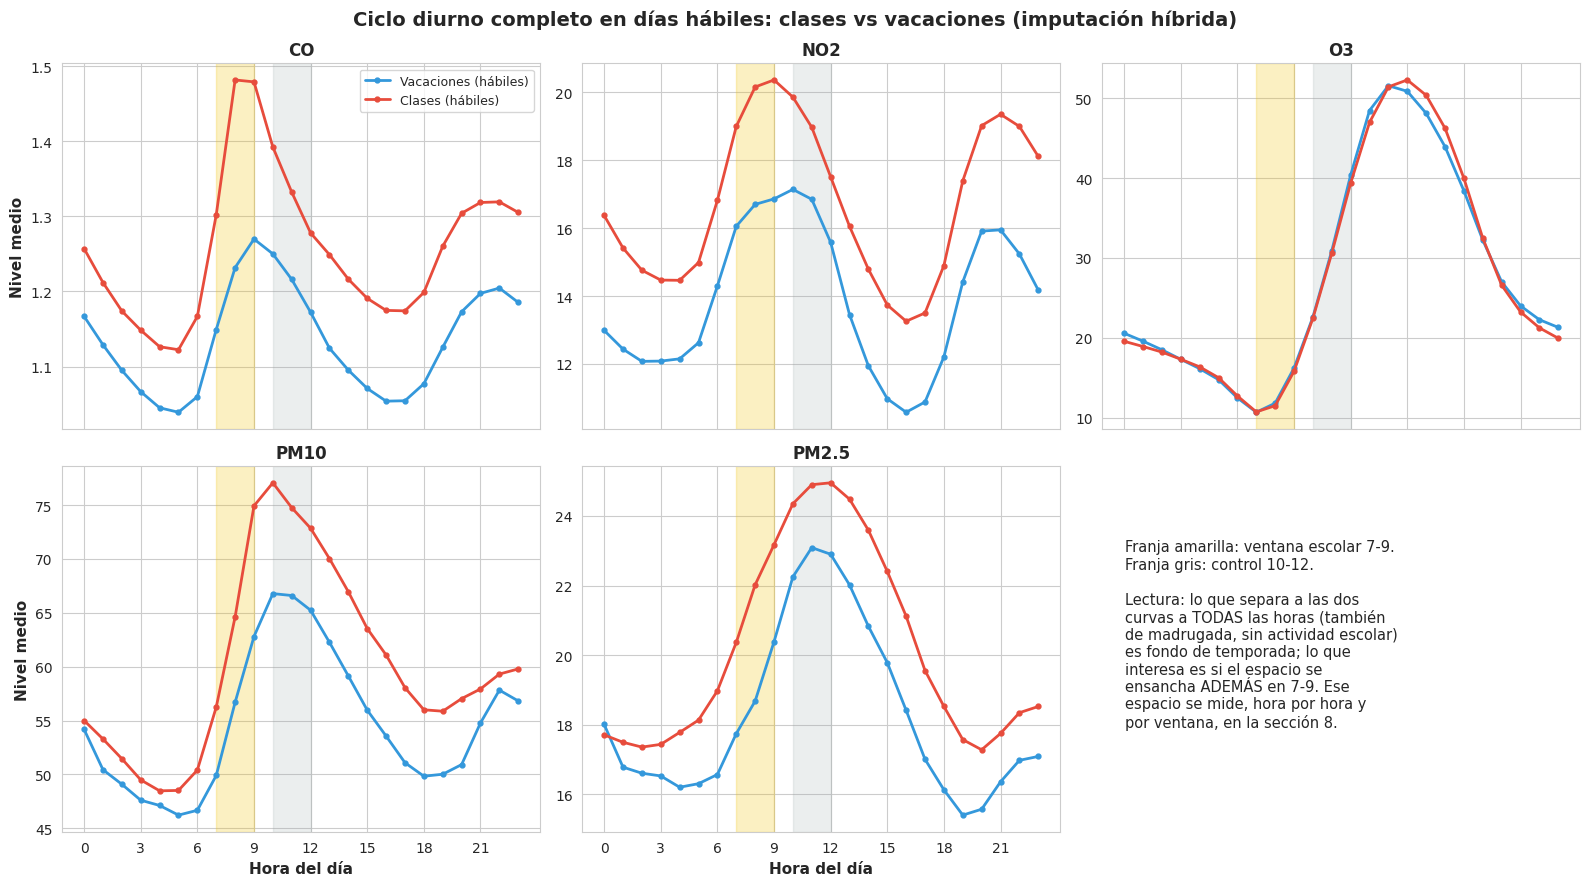

Guardado en: ../data_processed/perfil_horario/curvas_diurnas_por_regimen.csv
Guardado gráfico en: ../data_processed/perfil_horario/01_curvas_diurnas.png


In [3]:
curvas = entre_semana.groupby(['hora', 'clase'])[contaminantes].mean().reset_index()

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True)
axes = axes.flatten()

for i, c in enumerate(contaminantes):
    ax = axes[i]
    ax.axvspan(7, 9, color='#f1c40f', alpha=0.25)
    ax.axvspan(10, 12, color='#95a5a6', alpha=0.18)
    for cl, color, etiqueta in [(0, '#3498db', 'Vacaciones (hábiles)'), (1, '#e74c3c', 'Clases (hábiles)')]:
        sub = curvas[curvas['clase'] == cl]
        ax.plot(sub['hora'], sub[c], marker='o', markersize=3.5, color=color,
                label=etiqueta, linewidth=2)
    ax.set_title(c, fontsize=12, fontweight='bold')
    ax.set_xticks(range(0, 24, 3))
    if i >= 3:
        ax.set_xlabel('Hora del día', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Nivel medio', fontsize=11, fontweight='bold')
axes[3].set_ylabel('Nivel medio', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)
axes[5].axis('off')
axes[5].text(0.03, 0.8, 'Franja amarilla: ventana escolar 7-9.\nFranja gris: control 10-12.\n\nLectura: lo que separa a las dos\ncurvas a TODAS las horas (también\nde madrugada, sin actividad escolar)\nes fondo de temporada; lo que\ninteresa es si el espacio se\nensancha ADEMÁS en 7-9. Ese\nespacio se mide, hora por hora y\npor ventana, en la sección 8.',
             fontsize=10.5, va='top')
fig.suptitle('Ciclo diurno completo en días hábiles: clases vs vacaciones (imputación híbrida)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(perfil_dir / '01_curvas_diurnas.png', dpi=150, bbox_inches='tight')
plt.show()

curvas.to_csv(perfil_dir / 'curvas_diurnas_por_regimen.csv', index=False)
print(f"Guardado en: {perfil_dir / 'curvas_diurnas_por_regimen.csv'}")
print(f"Guardado gráfico en: {perfil_dir / '01_curvas_diurnas.png'}")

## 4. El efecto de clase HORA POR HORA, con controles

Para cada hora del día se estima la misma regresión del resto del análisis
(log nivel ~ clase + estación + mes + día de semana, errores por semana, solo días
hábiles). Las horas sin actividad escolar (madrugada, noche) son ventanas de
referencia: ahí el coeficiente debería ser ~0 si los controles hacen su trabajo.

### La ecuación, hora por hora

Para cada hora del día $h \in \{0, \dots, 23\}$ se estima POR SEPARADO

$$ \log y^{(h)}_{st} = \alpha_h + \beta_h\,\text{clase}_t + \eta_s + \gamma_{m(t)} + \delta_{d(t)} + \varepsilon^{(h)}_{st} $$

y se grafica $(e^{\beta_h}-1)\times 100$ con su IC. La curva de $\beta_h$ es una
prueba de consistencia en 24 ventanas: si la asociación viene de la entrada escolar,
debe concentrarse en $h = 7, 8$; en las horas sin actividad escolar (madrugada)
se espera $\beta_h \approx 0$, son ventanas de referencia gratis.

In [4]:
def contraste_en_hora(df_hora, columna_y):
    """
    OLS log(y) ~ clase + estación + mes + dow con errores agrupados por semana,
    para las observaciones de UNA hora del día.
    """
    df = df_hora.dropna(subset=[columna_y]).copy()
    X = pd.concat([pd.Series(1.0, index=df.index, name='const'), df['clase'].astype(float),
                   pd.get_dummies(df['estacion'], prefix='est', drop_first=True).astype(float),
                   pd.get_dummies(df['mes'], prefix='mes', drop_first=True).astype(float),
                   pd.get_dummies(df['dow'], prefix='dow', drop_first=True).astype(float)], axis=1)
    Xv = X.values
    n, k = Xv.shape
    XtX_inv = np.linalg.inv(Xv.T @ Xv)
    y = df[columna_y].values
    beta_todos = XtX_inv @ Xv.T @ y
    residuos = y - Xv @ beta_todos
    grupos = pd.factorize(df['wk'])[0]
    orden = np.argsort(grupos, kind='stable')
    Xo, ro, go = Xv[orden], residuos[orden], grupos[orden]
    inicios = np.flatnonzero(np.r_[True, go[1:] != go[:-1]])
    G = len(inicios)
    fines = np.r_[inicios[1:], len(go)]
    S = np.zeros((k, k))
    for s, e in zip(inicios, fines):
        zg = Xo[s:e].T @ ro[s:e]
        S += np.outer(zg, zg)
    V = XtX_inv @ S @ XtX_inv * (G / (G - 1)) * ((n - 1) / (n - k))
    idx = X.columns.get_loc('clase')
    beta, se = beta_todos[idx], np.sqrt(V[idx, idx])
    return beta, se

filas_horas = []
for hora in range(24):
    df_hora = entre_semana[entre_semana['hora'] == hora]
    for c in contaminantes:
        beta, se = contraste_en_hora(df_hora, f'l_{c}')
        filas_horas.append({'hora': hora, 'contaminante': c,
                            'pct': (np.exp(beta) - 1) * 100,
                            'ci_lo_pct': (np.exp(beta - 1.96 * se) - 1) * 100,
                            'ci_hi_pct': (np.exp(beta + 1.96 * se) - 1) * 100,
                            'p': 2 * (1 - stats.norm.cdf(abs(beta / se)))})
tabla_horas = pd.DataFrame(filas_horas)
tabla_horas[['pct', 'ci_lo_pct', 'ci_hi_pct']] = tabla_horas[['pct', 'ci_lo_pct', 'ci_hi_pct']].round(2)
tabla_horas['p'] = tabla_horas['p'].round(4)
tabla_horas.to_csv(perfil_dir / 'efecto_clase_por_hora.csv', index=False)
print(f"Guardado en: {perfil_dir / 'efecto_clase_por_hora.csv'}")

print("\nEFECTO DE CLASE POR HORA (CO, con controles):")
print(tabla_horas.query("contaminante == 'CO'")[['hora', 'pct', 'ci_lo_pct', 'ci_hi_pct', 'p']].to_string(index=False))

Guardado en: ../data_processed/perfil_horario/efecto_clase_por_hora.csv

EFECTO DE CLASE POR HORA (CO, con controles):
 hora   pct  ci_lo_pct  ci_hi_pct      p
    0 -0.80     -13.37      13.58 0.9071
    1 -0.70     -13.16      13.54 0.9177
    2 -0.38     -12.94      13.99 0.9562
    3  0.21     -12.50      14.77 0.9755
    4  0.38     -12.35      14.97 0.9559
    5  1.21     -11.54      15.79 0.8614
    6  3.67      -8.77      17.81 0.5805
    7  6.76      -5.53      20.64 0.2946
    8 10.52      -1.57      24.11 0.0907
    9  7.41      -4.14      20.36 0.2180
   10  4.02      -7.29      16.71 0.5021
   11  2.16      -8.94      14.60 0.7161
   12  2.02      -9.35      14.81 0.7404
   13  2.54      -9.25      15.86 0.6872
   14  2.41      -9.62      16.03 0.7092
   15  2.51      -9.89      16.62 0.7060
   16  2.40     -10.24      16.81 0.7241
   17  2.73     -10.13      17.43 0.6927
   18  2.67     -10.22      17.42 0.7001
   19  2.89      -9.70      17.24 0.6688
   20  2.33      -9.

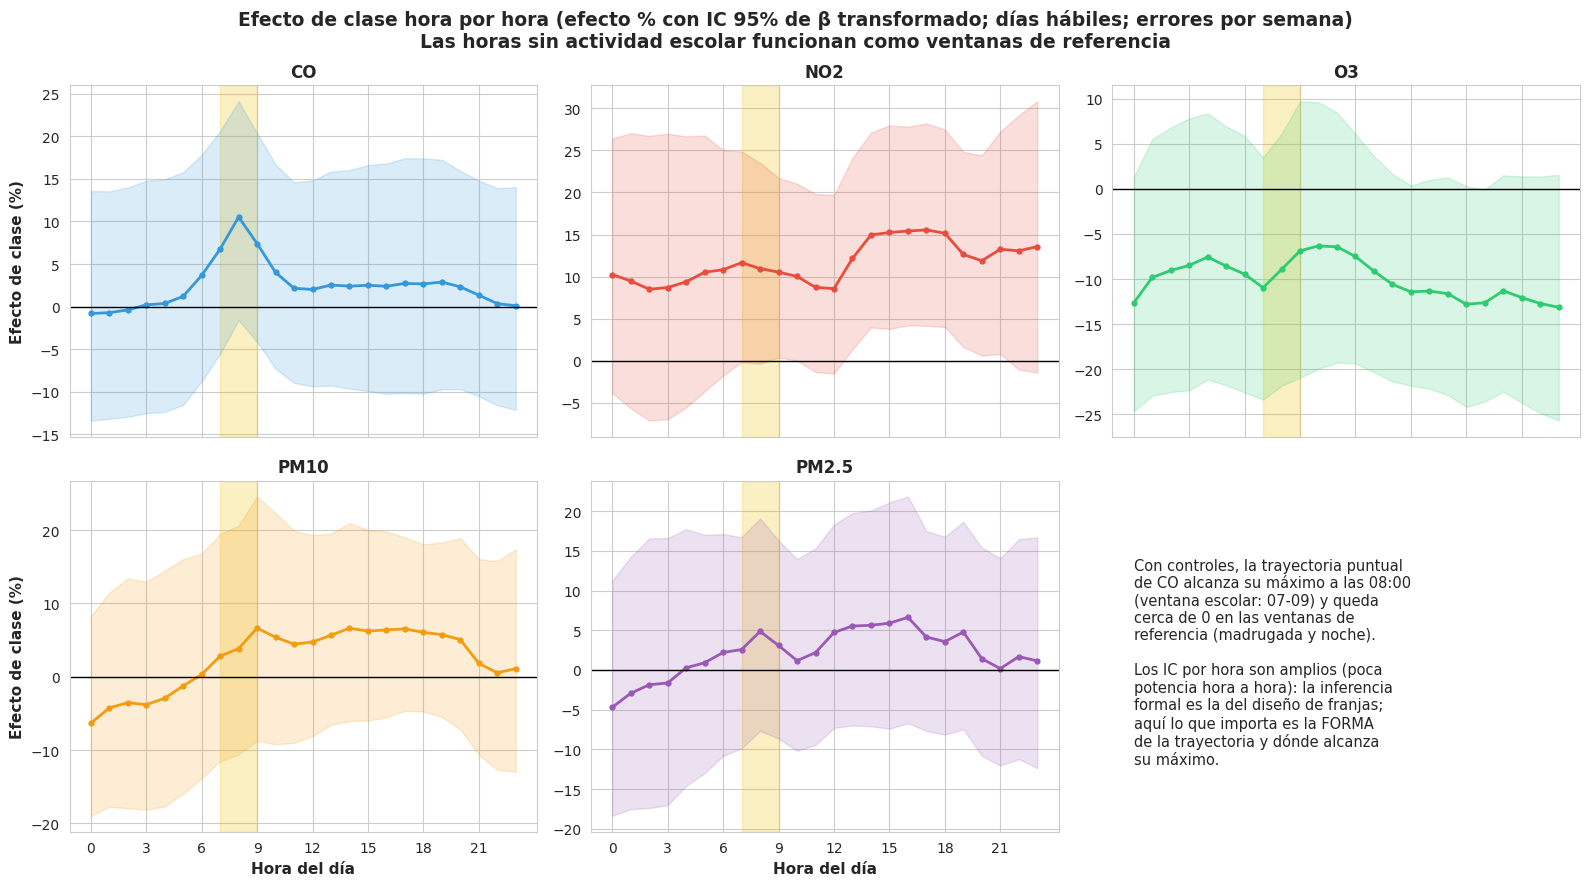

Guardado gráfico en: ../data_processed/perfil_horario/02_efecto_por_hora.png


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True)
axes = axes.flatten()

for i, c in enumerate(contaminantes):
    ax = axes[i]
    sub = tabla_horas[tabla_horas['contaminante'] == c]
    ax.axvspan(7, 9, color='#f1c40f', alpha=0.25)
    ax.fill_between(sub['hora'], sub['ci_lo_pct'], sub['ci_hi_pct'],
                    color=colores_contaminantes[c], alpha=0.18)
    ax.plot(sub['hora'], sub['pct'], marker='o', markersize=3.5,
            color=colores_contaminantes[c], linewidth=2)
    ax.axhline(0, color='black', linewidth=1)
    ax.set_title(c, fontsize=12, fontweight='bold')
    ax.set_xticks(range(0, 24, 3))
    if i >= 3:
        ax.set_xlabel('Hora del día', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Efecto de clase (%)', fontsize=11, fontweight='bold')
axes[3].set_ylabel('Efecto de clase (%)', fontsize=11, fontweight='bold')
axes[5].axis('off')
hora_max_co = int(tabla_horas[tabla_horas['contaminante'] == 'CO'].set_index('hora')['pct'].idxmax())
axes[5].text(0.03, 0.78, f'Con controles, la trayectoria puntual\nde CO alcanza su máximo a las {hora_max_co:02d}:00\n(ventana escolar: 07-09) y queda\ncerca de 0 en las ventanas de\nreferencia (madrugada y noche).\n\nLos IC por hora son amplios (poca\npotencia hora a hora): la inferencia\nformal es la del diseño de franjas;\naquí lo que importa es la FORMA\nde la trayectoria y dónde alcanza\nsu máximo.',
             fontsize=10.5, va='top')
fig.suptitle('Efecto de clase hora por hora (efecto % con IC 95% de β transformado; días hábiles; errores por semana)\nLas horas sin actividad escolar funcionan como ventanas de referencia',
             fontsize=13.5, fontweight='bold')
plt.tight_layout()
plt.savefig(perfil_dir / '02_efecto_por_hora.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Guardado gráfico en: {perfil_dir / '02_efecto_por_hora.png'}")

## 5. Verificación con la imputación MIMA (misma trayectoria horaria)

In [6]:
panel_horario_mima = cargar_panel_horario('../data_processed/datos_horarios_imputados_MIMA.csv.gz', 'MIMA')
entre_semana_mima = panel_horario_mima[panel_horario_mima['dow'] < 5]

trayectoria_mima = []
for hora in range(24):
    beta, se = contraste_en_hora(entre_semana_mima[entre_semana_mima['hora'] == hora], 'l_CO')
    trayectoria_mima.append((np.exp(beta) - 1) * 100)
trayectoria_hibrido = tabla_horas.query("contaminante == 'CO'")['pct'].values
correlacion_trayectorias = np.corrcoef(trayectoria_hibrido, trayectoria_mima)[0, 1]

print("=" * 70)
print("VERIFICACIÓN MIMA: TRAYECTORIA HORARIA DEL EFECTO DE CO")
print("=" * 70)
print(f"Correlación entre la trayectoria híbrida y la MIMA (24 horas): {correlacion_trayectorias:.3f}")
print(f"Hora 7 — híbrido: {trayectoria_hibrido[7]:+.1f}% | MIMA: {trayectoria_mima[7]:+.1f}%")
print(f"Hora 8 — híbrido: {trayectoria_hibrido[8]:+.1f}% | MIMA: {trayectoria_mima[8]:+.1f}%")

[MIMA] panel horario: 157,824 filas hora-día-estación
VERIFICACIÓN MIMA: TRAYECTORIA HORARIA DEL EFECTO DE CO
Correlación entre la trayectoria híbrida y la MIMA (24 horas): 0.997
Hora 7 — híbrido: +6.8% | MIMA: +6.1%
Hora 8 — híbrido: +10.5% | MIMA: +10.0%


## 6. Heterogeneidad por estación de monitoreo

Si la asociación de CO viene del tráfico de entrada escolar, se espera más visible en
estaciones céntricas/de tráfico que en las periféricas. Se estima el gap DiD
de franjas por estación, para CO y NO2.

In [7]:
gaps = pd.read_csv('../data_processed/gaps_franjas_hibrido.csv', parse_dates=['date'])

def contraste_gap_estacion(df_estacion, columna_y):
    """
    gap ~ clase + mes + dow con errores por semana, dentro de UNA estación.
    """
    df = df_estacion.dropna(subset=[columna_y]).copy()
    X = pd.concat([pd.Series(1.0, index=df.index, name='const'), df['clase'].astype(float),
                   pd.get_dummies(df['mes'], prefix='mes', drop_first=True).astype(float),
                   pd.get_dummies(df['dow'], prefix='dow', drop_first=True).astype(float)], axis=1)
    Xv = X.values
    n, k = Xv.shape
    XtX_inv = np.linalg.inv(Xv.T @ Xv)
    y = df[columna_y].values
    beta_todos = XtX_inv @ Xv.T @ y
    residuos = y - Xv @ beta_todos
    grupos = pd.factorize(df['wk'])[0]
    orden = np.argsort(grupos, kind='stable')
    Xo, ro, go = Xv[orden], residuos[orden], grupos[orden]
    inicios = np.flatnonzero(np.r_[True, go[1:] != go[:-1]])
    G = len(inicios)
    fines = np.r_[inicios[1:], len(go)]
    S = np.zeros((k, k))
    for s, e in zip(inicios, fines):
        zg = Xo[s:e].T @ ro[s:e]
        S += np.outer(zg, zg)
    V = XtX_inv @ S @ XtX_inv * (G / (G - 1)) * ((n - 1) / (n - k))
    idx = X.columns.get_loc('clase')
    beta, se = beta_todos[idx], np.sqrt(V[idx, idx])
    return beta, se, n

filas_estaciones = []
for estacion_m in sorted(gaps['estacion'].unique()):
    sub = gaps[gaps['estacion'] == estacion_m]
    for c in ['CO', 'NO2']:
        beta, se, n = contraste_gap_estacion(sub, f'gap_{c}')
        filas_estaciones.append({'estacion': estacion_m, 'contaminante': c,
                                 'pct': round((np.exp(beta) - 1) * 100, 2),
                                 'ci_lo_pct': round((np.exp(beta - 1.96 * se) - 1) * 100, 2),
                                 'ci_hi_pct': round((np.exp(beta + 1.96 * se) - 1) * 100, 2),
                                 'p': round(2 * (1 - stats.norm.cdf(abs(beta / se))), 4), 'n': n})
tabla_estaciones = pd.DataFrame(filas_estaciones)

print("=" * 70)
print("GAP DiD POR ESTACIÓN DE MONITOREO (CO y NO2)")
print("=" * 70)
print(tabla_estaciones.to_string(index=False))
tabla_estaciones.to_csv(perfil_dir / 'gap_did_por_estacion.csv', index=False)
print(f"\nGuardado en: {perfil_dir / 'gap_did_por_estacion.csv'}")

GAP DiD POR ESTACIÓN DE MONITOREO (CO y NO2)
 estacion contaminante   pct  ci_lo_pct  ci_hi_pct      p    n
   CENTRO           CO  1.87      -0.87       4.69 0.1836 1096
   CENTRO          NO2  6.60      -1.87      15.80 0.1305 1096
 NORESTE3           CO  4.61       1.38       7.95 0.0049 1096
 NORESTE3          NO2 -1.35      -9.13       7.10 0.7463 1096
NOROESTE3           CO  3.38      -1.39       8.38 0.1680 1096
NOROESTE3          NO2 -1.70     -10.24       7.64 0.7109 1096
   NORTE2           CO  6.67       1.59      12.01 0.0095 1096
   NORTE2          NO2 -1.68      -9.62       6.95 0.6932 1096
      SUR           CO  2.91      -0.26       6.18 0.0727 1096
      SUR          NO2  4.69      -3.53      13.60 0.2719 1096
SUROESTE2           CO  8.03       2.25      14.13 0.0059 1096
SUROESTE2          NO2 -0.10      -8.63       9.22 0.9820 1096

Guardado en: ../data_processed/perfil_horario/gap_did_por_estacion.csv


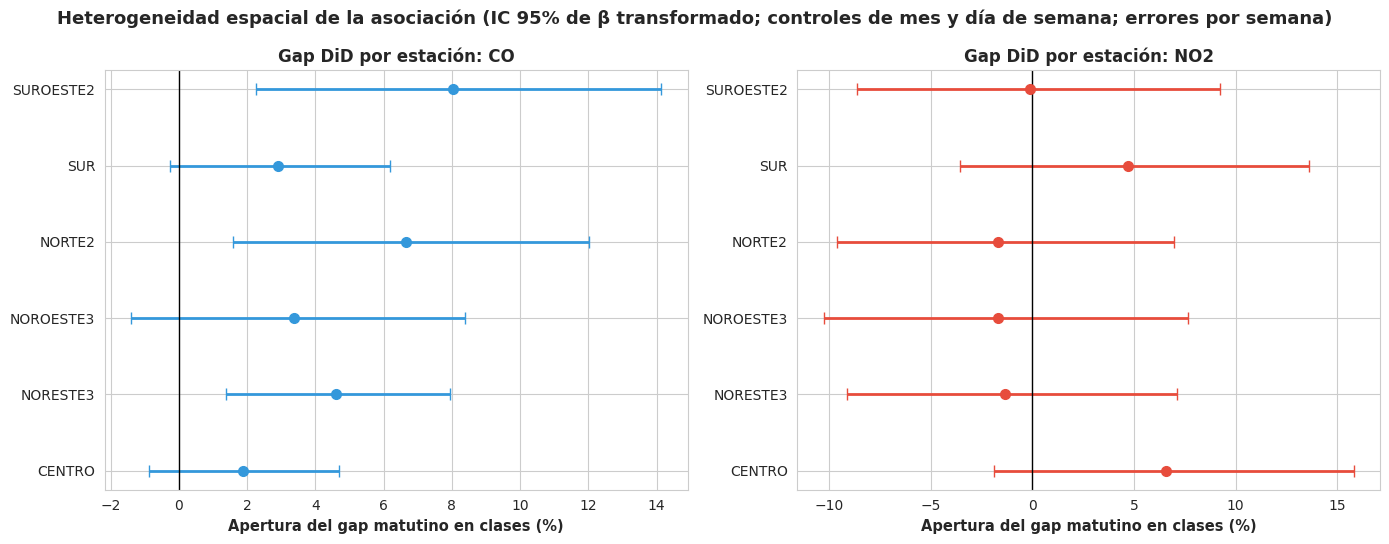

Guardado gráfico en: ../data_processed/perfil_horario/03_gap_por_estacion.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=False)

for ax, c in zip(axes, ['CO', 'NO2']):
    sub = tabla_estaciones[tabla_estaciones['contaminante'] == c].reset_index(drop=True)
    y_pos = np.arange(len(sub))
    ax.errorbar(sub['pct'], y_pos,
                xerr=[sub['pct'] - sub['ci_lo_pct'], sub['ci_hi_pct'] - sub['pct']],
                fmt='o', color=colores_contaminantes[c], markersize=7,
                capsize=4, linewidth=2)
    ax.axvline(0, color='black', linewidth=1)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(sub['estacion'])
    ax.set_title(f'Gap DiD por estación: {c}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Apertura del gap matutino en clases (%)', fontsize=10.5, fontweight='bold')

fig.suptitle('Heterogeneidad espacial de la asociación (IC 95% de β transformado; controles de mes y día de semana; errores por semana)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(perfil_dir / '03_gap_por_estacion.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Guardado gráfico en: {perfil_dir / '03_gap_por_estacion.png'}")

## 7. Niveles de partículas frente a las guías OMS 2021 (contexto de salud)

Solo PM10 y PM2.5 (unidades µg/m³ inequívocas en el monitoreo). Promedios de todo
el periodo (todas las horas) por estación, comparados con la guía ANUAL de la OMS
(PM2.5: 5 µg/m³; PM10: 15 µg/m³).

In [9]:
guias_oms = {'PM10': 15.0, 'PM2.5': 5.0}
promedios_pm = (panel_horario.groupby('estacion')[['PM10', 'PM2.5']].mean().round(1))
tabla_oms = promedios_pm.copy()
for c in ['PM10', 'PM2.5']:
    tabla_oms[f'{c}_veces_guia'] = (promedios_pm[c] / guias_oms[c]).round(1)

print("=" * 70)
print("PROMEDIOS DEL PERIODO COMPLETO VS GUÍA ANUAL OMS 2021")
print("=" * 70)
print(tabla_oms)
print(f"\nPromedio metropolitano: PM2.5 = {panel_horario['PM2.5'].mean():.1f} µg/m³ "
      f"({panel_horario['PM2.5'].mean()/guias_oms['PM2.5']:.1f}x la guía anual OMS de 5 µg/m³)")
print(f"                        PM10  = {panel_horario['PM10'].mean():.1f} µg/m³ "
      f"({panel_horario['PM10'].mean()/guias_oms['PM10']:.1f}x la guía anual OMS de 15 µg/m³)")
print("\nNota: promedios del periodo 2023-01 a 2025-06 con datos imputados; se usan como")
print("contexto de salud para el paper (el argumento causal del paper no depende de esto).")

tabla_oms.to_csv(perfil_dir / 'niveles_pm_vs_guia_oms.csv')
print(f"\nGuardado en: {perfil_dir / 'niveles_pm_vs_guia_oms.csv'}")

PROMEDIOS DEL PERIODO COMPLETO VS GUÍA ANUAL OMS 2021
parametro  PM10  PM2.5  PM10_veces_guia  PM2.5_veces_guia
estacion                                                 
CENTRO     56.3   22.0              3.8               4.4
NORESTE3   55.8   20.9              3.7               4.2
NOROESTE3  56.1   16.8              3.7               3.4
NORTE2     61.0   18.0              4.1               3.6
SUR        56.4   19.9              3.8               4.0
SUROESTE2  59.5   21.6              4.0               4.3

Promedio metropolitano: PM2.5 = 19.9 µg/m³ (4.0x la guía anual OMS de 5 µg/m³)
                        PM10  = 57.5 µg/m³ (3.8x la guía anual OMS de 15 µg/m³)

Nota: promedios del periodo 2023-01 a 2025-06 con datos imputados; se usan como
contexto de salud para el paper (el argumento causal del paper no depende de esto).

Guardado en: ../data_processed/perfil_horario/niveles_pm_vs_guia_oms.csv


## 8. La integral del espacio entre las curvas

El espacio entre la curva de clases y la de vacaciones no es exclusivo de CO: también
puede verse en otros contaminantes, y lo que importa es si se ensancha en la ventana 7-9. Aquí se mide ese espacio hora por hora y como ÁREA (integral) por
ventana del día, en dos monedas: unidades físicas x hora (exposición) y porcentaje.
La resta entre ventanas (pico menos control, pico menos madrugada) es la versión
integral de la doble diferencia: separa el ensanchamiento matutino del fondo estacional.

### La integral como doble diferencia

El espacio crudo entre curvas a la hora $h$ es $e_h = \bar y^{\text{clase}}_h / \bar y^{\text{vac}}_h - 1$
(en %), y el área de una ventana $[h_1, h_2]$ es

$$ A_{[h_1,h_2]} = \sum_{h=h_1}^{h_2} \big(\bar y^{\text{clase}}_h - \bar y^{\text{vac}}_h\big) $$

en unidades físicas × hora — una exposición acumulada. La resta entre ventanas,
$e_{\text{pico}} - e_{\text{control}}$, es la versión integral de la doble
diferencia del notebook 05: el fondo compartido (temporada) vive en las dos
ventanas y se cancela; sobrevive solo el ensanchamiento específico de la mañana.
(Esta versión es cruda, sin controles de composición; la formal, con controles de
mes y día, es la del notebook 05.)

In [10]:
ventanas = {'madrugada_0_5': range(0, 6), 'pico_7_9': [7, 8], 'control_10_12': [10, 11],
            'tarde_13_18': range(13, 19), 'noche_19_23': range(19, 24)}

espacio_por_hora = {}
area_filas = []
for c in contaminantes:
    ancho_c = curvas.pivot(index='hora', columns='clase', values=c)
    espacio_pct = (ancho_c[1] / ancho_c[0] - 1) * 100
    espacio_abs = ancho_c[1] - ancho_c[0]
    espacio_por_hora[c] = espacio_pct
    for nombre_v, horas_v in ventanas.items():
        horas_v = list(horas_v)
        area_filas.append({'contaminante': c, 'ventana': nombre_v,
                           'espacio_promedio_pct': round(espacio_pct.loc[horas_v].mean(), 1),
                           'area_unidades_h': round(espacio_abs.loc[horas_v].sum(), 2),
                           'horas': len(horas_v)})

tabla_espacio_hora = pd.DataFrame(espacio_por_hora).round(1)
tabla_espacio_hora.to_csv(perfil_dir / 'espacio_crudo_por_hora.csv')
tabla_areas = pd.DataFrame(area_filas)
tabla_areas.to_csv(perfil_dir / 'espacio_por_ventana.csv', index=False)

print("=" * 70)
print("ESPACIO CRUDO ENTRE CURVAS (%), PROMEDIO POR VENTANA")
print("=" * 70)
print(tabla_areas.pivot(index='contaminante', columns='ventana', values='espacio_promedio_pct')
      [['madrugada_0_5', 'pico_7_9', 'control_10_12', 'tarde_13_18', 'noche_19_23']])

print("\nLA DOBLE DIFERENCIA COMO INTEGRAL (puntos porcentuales de espacio):")
print(f"{'':>6} {'pico-control':>14} {'pico-madrugada':>16}")
esp = tabla_areas.pivot(index='contaminante', columns='ventana', values='espacio_promedio_pct')
for c in contaminantes:
    d_control = esp.loc[c, 'pico_7_9'] - esp.loc[c, 'control_10_12']
    d_madrugada = esp.loc[c, 'pico_7_9'] - esp.loc[c, 'madrugada_0_5']
    print(f"{c:>6} {d_control:>+13.1f} {d_madrugada:>+15.1f}")
lideres = [c for c in ['CO', 'NO2', 'PM10', 'PM2.5'] if esp.loc[c, 'pico_7_9'] - esp.loc[c, 'control_10_12'] > 0]
print("\n=> El fondo estacional vive a todas horas (madrugada incluida); el ensanchamiento")
print("   EXTRA de la ventana escolar es lo que sobrevive a la resta. En esta versión CRUDA")
print(f"   el ensanchamiento pico-control es positivo para: {', '.join(lideres) if lideres else 'ninguno'}.")
print("   La versión formal, con controles de mes y día de semana, es la del notebook 05.")
o3_pico = esp.loc['O3', 'pico_7_9']
o3_control = esp.loc['O3', 'control_10_12']
if o3_pico < o3_control:
    print(f"=> Química: el espacio de O3 en la mañana escolar cae por DEBAJO del de la franja")
    print(f"   control ({o3_pico:+.1f}% en 7-9 contra {o3_control:+.1f}% en 10-12): el tráfico fresco")
    print("   consume ozono (titulación por NO), la firma química de emisión vehicular.")
else:
    print(f"=> Química: el espacio de O3 en la mañana escolar ({o3_pico:+.1f}% en 7-9) no cae por debajo")
    print(f"   del de la franja control ({o3_control:+.1f}% en 10-12): sin firma clara de titulación.")
print(f"\nGuardado en: {perfil_dir / 'espacio_crudo_por_hora.csv'}")
print(f"Guardado en: {perfil_dir / 'espacio_por_ventana.csv'}")

ESPACIO CRUDO ENTRE CURVAS (%), PROMEDIO POR VENTANA
ventana       madrugada_0_5  pico_7_9  control_10_12  tarde_13_18  noche_19_23
contaminante                                                                  
CO                      7.6      16.8           10.5         11.2         10.6
NO2                    21.6      19.5           14.2         23.3         22.8
O3                     -1.1      -1.1           -0.9          2.2         -3.0
PM10                    4.0      13.4           13.8         13.2          7.5
PM2.5                   5.6      16.3            8.6         13.7         10.0

LA DOBLE DIFERENCIA COMO INTEGRAL (puntos porcentuales de espacio):
         pico-control   pico-madrugada
    CO          +6.3            +9.2
   NO2          +5.3            -2.1
    O3          -0.2            +0.0
  PM10          -0.4            +9.4
 PM2.5          +7.7           +10.7

=> El fondo estacional vive a todas horas (madrugada incluida); el ensanchamiento
   EXTRA de la ven

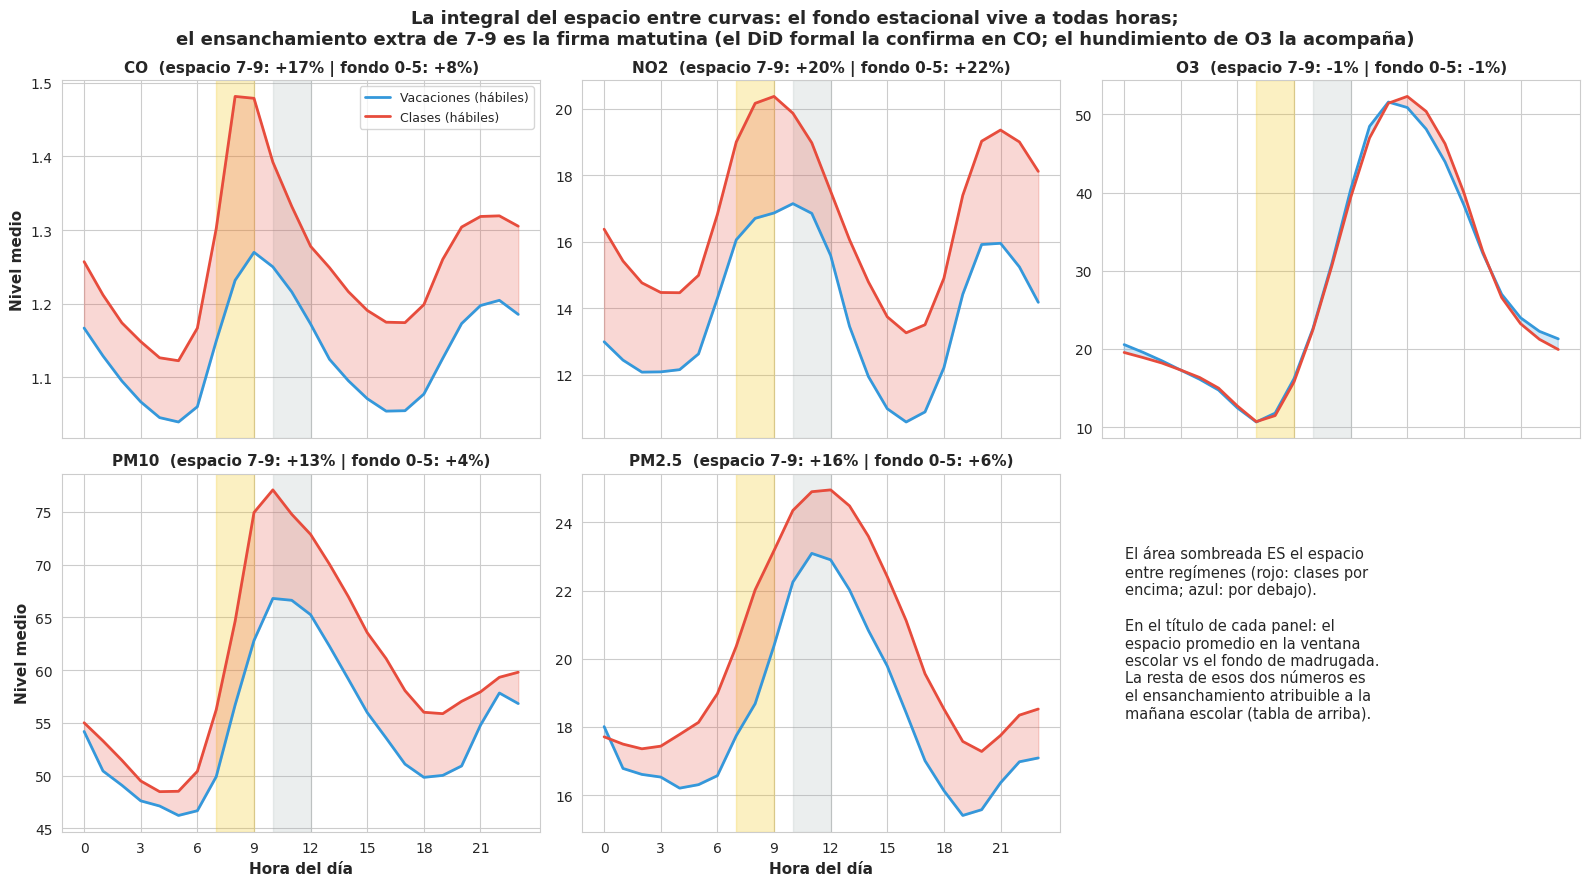

Guardado gráfico en: ../data_processed/perfil_horario/04_espacio_entre_curvas.png

FINALIZADO


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True)
axes = axes.flatten()

for i, c in enumerate(contaminantes):
    ax = axes[i]
    ancho_c = curvas.pivot(index='hora', columns='clase', values=c)
    ax.axvspan(7, 9, color='#f1c40f', alpha=0.25)
    ax.axvspan(10, 12, color='#95a5a6', alpha=0.18)
    ax.plot(ancho_c.index, ancho_c[0], color='#3498db', linewidth=2, label='Vacaciones (hábiles)')
    ax.plot(ancho_c.index, ancho_c[1], color='#e74c3c', linewidth=2, label='Clases (hábiles)')
    ax.fill_between(ancho_c.index, ancho_c[0], ancho_c[1],
                    where=(ancho_c[1] >= ancho_c[0]), color='#e74c3c', alpha=0.22, interpolate=True)
    ax.fill_between(ancho_c.index, ancho_c[0], ancho_c[1],
                    where=(ancho_c[1] < ancho_c[0]), color='#3498db', alpha=0.22, interpolate=True)
    pico = esp.loc[c, 'pico_7_9']
    fondo = esp.loc[c, 'madrugada_0_5']
    ax.set_title(f"{c}  (espacio 7-9: {pico:+.0f}% | fondo 0-5: {fondo:+.0f}%)",
                 fontsize=11, fontweight='bold')
    ax.set_xticks(range(0, 24, 3))
    if i >= 3:
        ax.set_xlabel('Hora del día', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Nivel medio', fontsize=11, fontweight='bold')
axes[3].set_ylabel('Nivel medio', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)
axes[5].axis('off')
axes[5].text(0.03, 0.8, 'El área sombreada ES el espacio\nentre regímenes (rojo: clases por\nencima; azul: por debajo).\n\nEn el título de cada panel: el\nespacio promedio en la ventana\nescolar vs el fondo de madrugada.\nLa resta de esos dos números es\nel ensanchamiento atribuible a la\nmañana escolar (tabla de arriba).',
             fontsize=10.5, va='top')
fig.suptitle('La integral del espacio entre curvas: el fondo estacional vive a todas horas;\nel ensanchamiento extra de 7-9 es la firma matutina (el DiD formal la confirma en CO; el hundimiento de O3 la acompaña)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(perfil_dir / '04_espacio_entre_curvas.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Guardado gráfico en: {perfil_dir / '04_espacio_entre_curvas.png'}")

print('\nFINALIZADO')